In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("📁 Path to dataset files:", path)

csv_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(csv_file)

print(f"\n✅ Dataset Loaded!")
print(f"📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
📁 Path to dataset files: /kaggle/input/telco-customer-churn

✅ Dataset Loaded!
📐 Shape: 7043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# ── 4.1 Drop irrelevant column
df.drop(columns=['customerID'], inplace=True)

In [6]:
# ── 4.2 Fix TotalCharges (object → numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
# ── 4.3 Missing values check
missing = df.isnull().sum()
print(missing[missing > 0])

TotalCharges    11
dtype: int64


In [8]:
# ── 4.4 Fill missing TotalCharges with median
median_tc = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_tc, inplace=True)
print(f"\n✅ Missing 'TotalCharges' filled with median: {median_tc:.2f}")


✅ Missing 'TotalCharges' filled with median: 1397.47


In [9]:
# ── 4.5 Duplicate check
dups = df.duplicated().sum()
print(f"\n🔍 Duplicate rows: {dups}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print("✅ Duplicates removed!")
else:
    print("✅ No duplicates found!")


🔍 Duplicate rows: 22
✅ Duplicates removed!


In [10]:
# ── 4.6 Strip whitespace from object columns
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].apply(lambda x: x.str.strip())
print("\n✅ Whitespace stripped from all string columns")


✅ Whitespace stripped from all string columns


In [11]:
print(f"\n📐 Cleaned Shape: {df.shape}")
df.head(3)


📐 Cleaned Shape: (7021, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


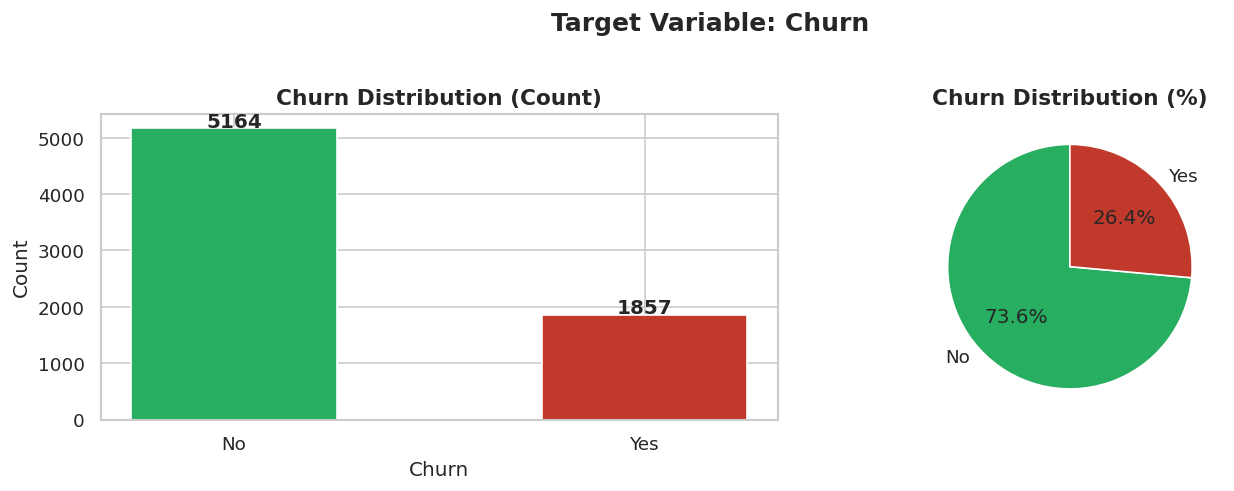

💾 Saved: DT_01_churn_distribution.png


In [12]:
# ── 5.1 Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Churn'].value_counts()

axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#27ae60', '#c0392b'], edgecolor='white', width=0.5)
axes[0].set_title('Churn Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#27ae60', '#c0392b'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Churn Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('DT_01_churn_distribution.png', bbox_inches='tight')
plt.show()
print("💾 Saved: DT_01_churn_distribution.png")

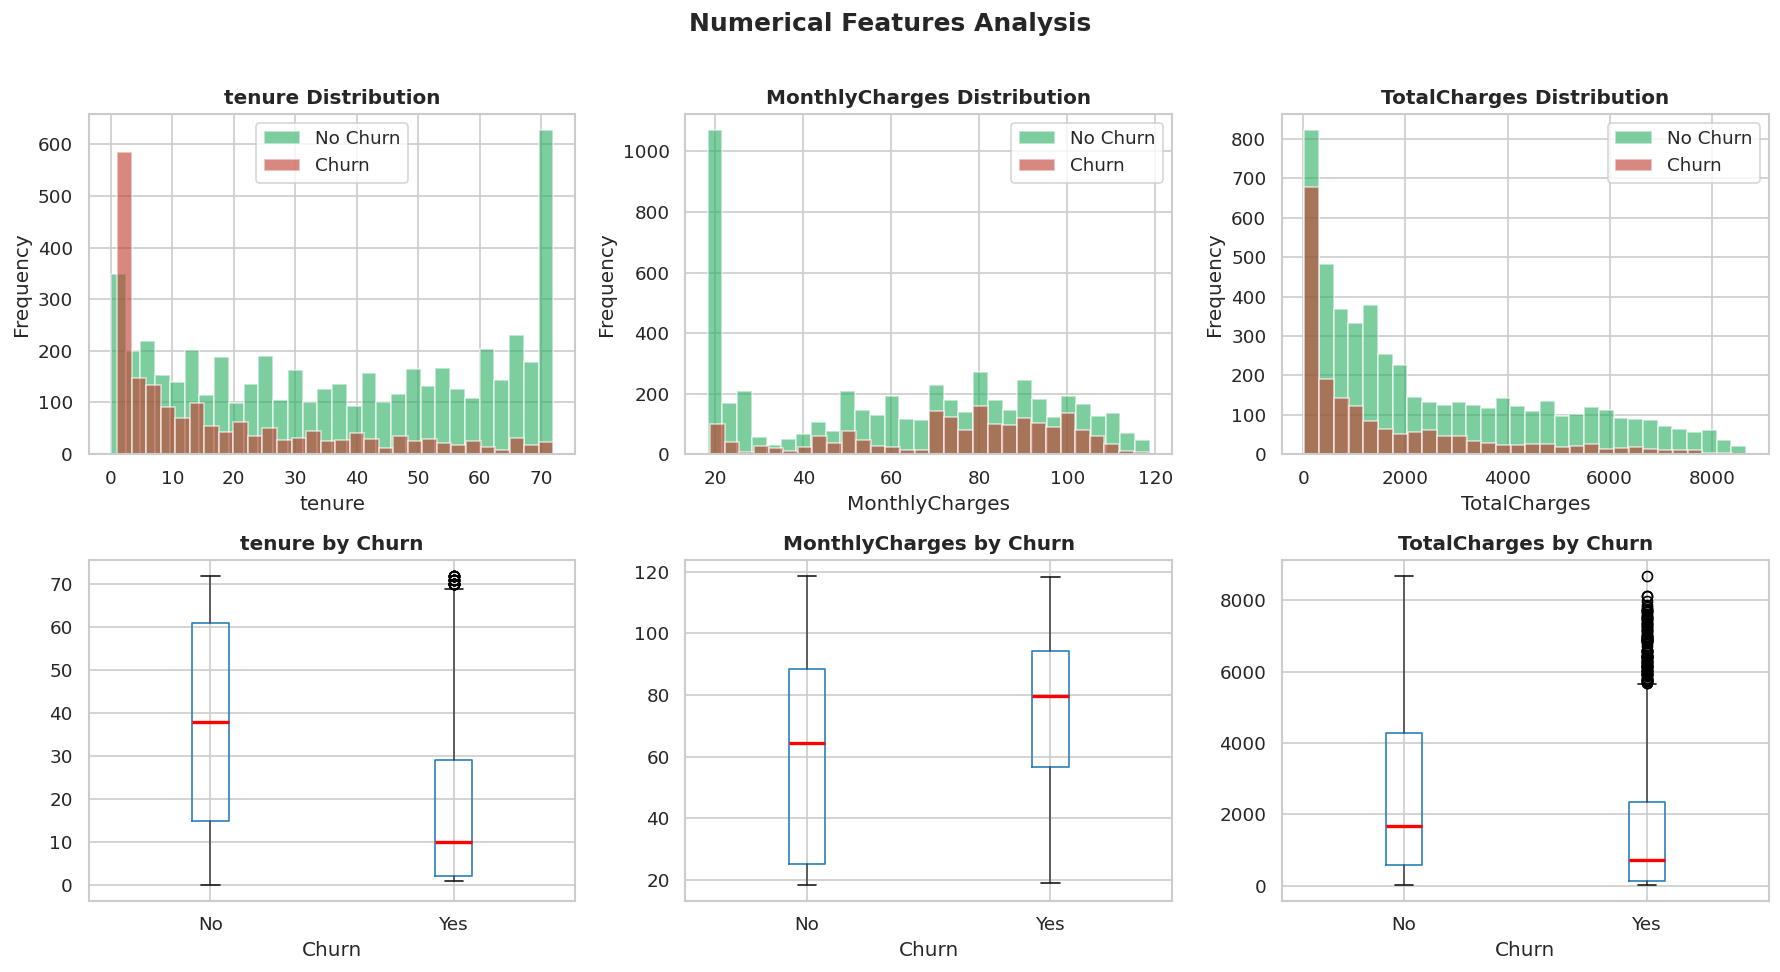

💾 Saved: DT_02_numerical_features.png


In [13]:
# ── 5.2 Numerical Features Distribution by Churn
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[df['Churn'] == 'No'][col],  bins=30,
                    alpha=0.6, color='#27ae60', label='No Churn')
    axes[0, i].hist(df[df['Churn'] == 'Yes'][col], bins=30,
                    alpha=0.6, color='#c0392b', label='Churn')
    axes[0, i].set_title(f'{col} Distribution', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')
    axes[0, i].legend()

    # Boxplot
    df.boxplot(column=col, by='Churn', ax=axes[1, i],
               boxprops=dict(color='#2980b9'),
               medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'{col} by Churn', fontweight='bold')
    axes[1, i].set_xlabel('Churn')

plt.suptitle('Numerical Features Analysis', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('DT_02_numerical_features.png', bbox_inches='tight')
plt.show()
print("💾 Saved: DT_02_numerical_features.png")

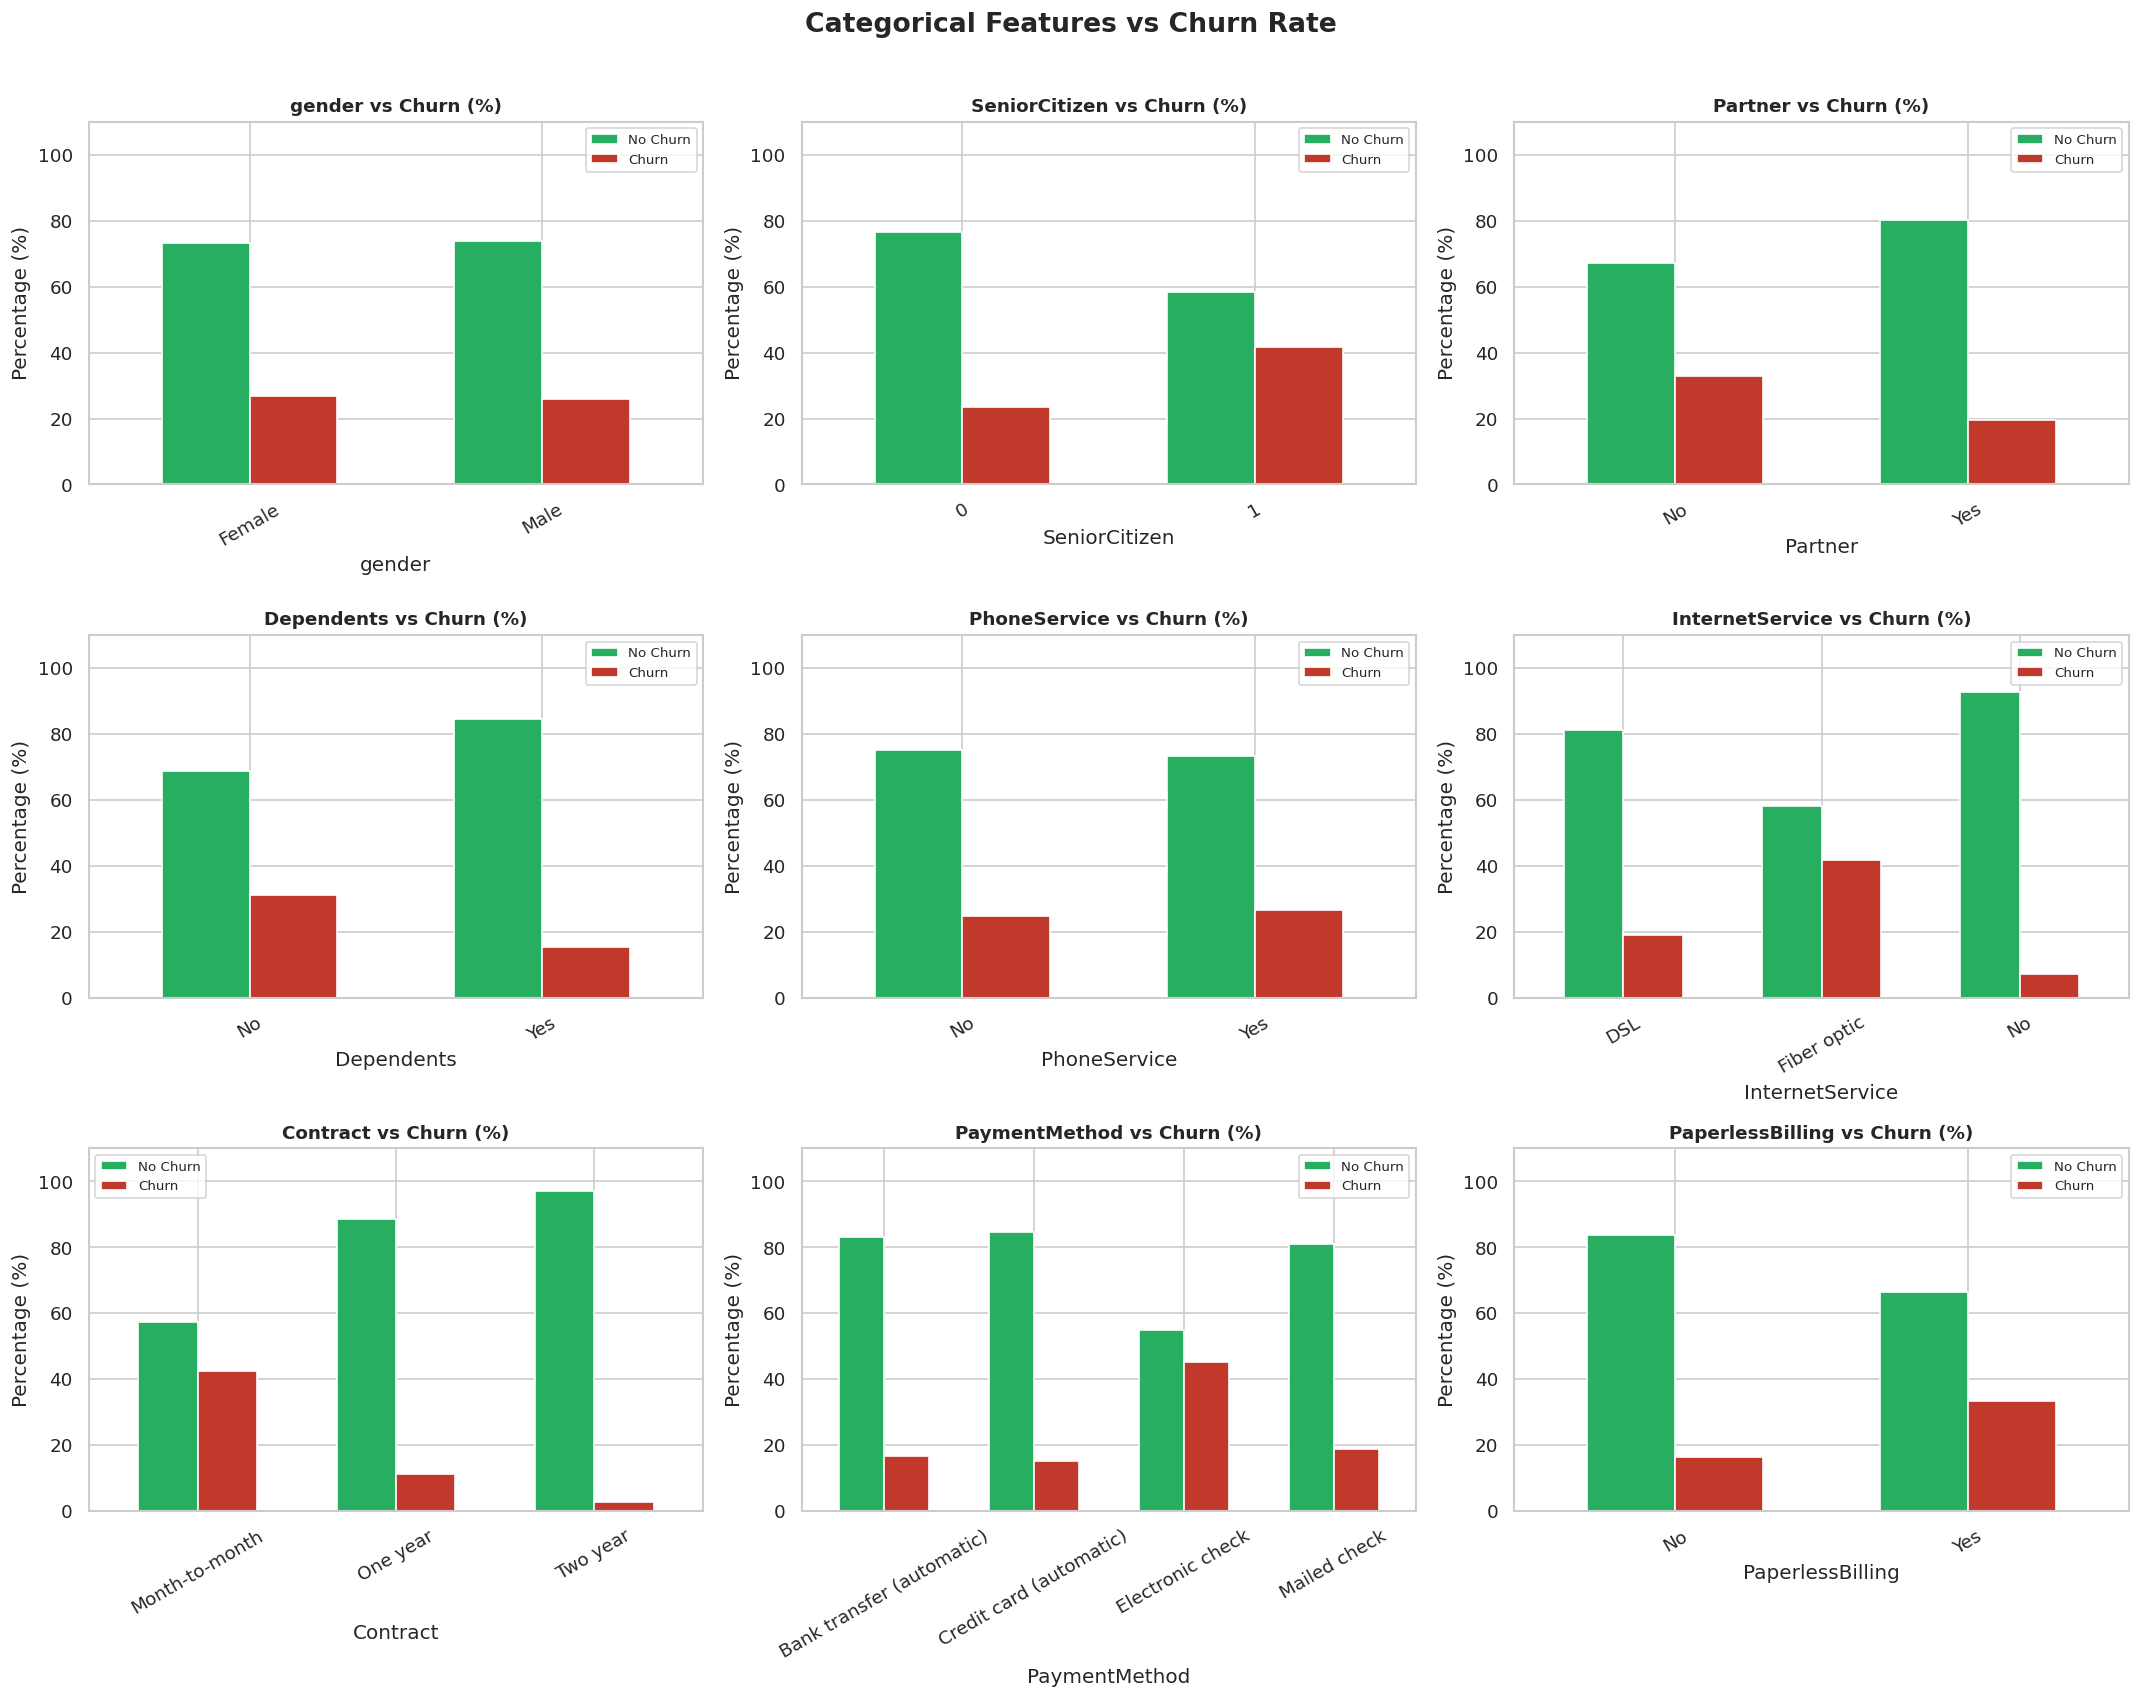

💾 Saved: DT_03_categorical_features.png


In [14]:
# ── 5.3 Categorical Features vs Churn
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'InternetService', 'Contract',
            'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i],
            color=['#27ae60', '#c0392b'],
            edgecolor='white', width=0.6)
    axes[i].set_title(f'{col} vs Churn (%)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['No Churn', 'Churn'], fontsize=8)
    axes[i].set_ylim(0, 110)

plt.suptitle('Categorical Features vs Churn Rate',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('DT_03_categorical_features.png', bbox_inches='tight')
plt.show()
print("💾 Saved: DT_03_categorical_features.png")

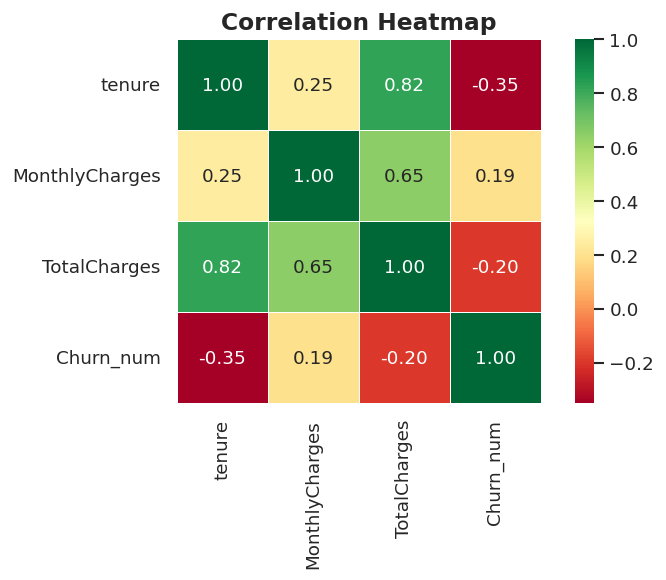

💾 Saved: DT_04_correlation_heatmap.png


In [15]:
# ── 5.4 Correlation Heatmap
fig, ax = plt.subplots(figsize=(7, 5))

corr_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
corr_df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

sns.heatmap(corr_df.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5,
            ax=ax, square=True, annot_kws={'fontsize': 11})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('DT_04_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("💾 Saved: DT_04_correlation_heatmap.png")

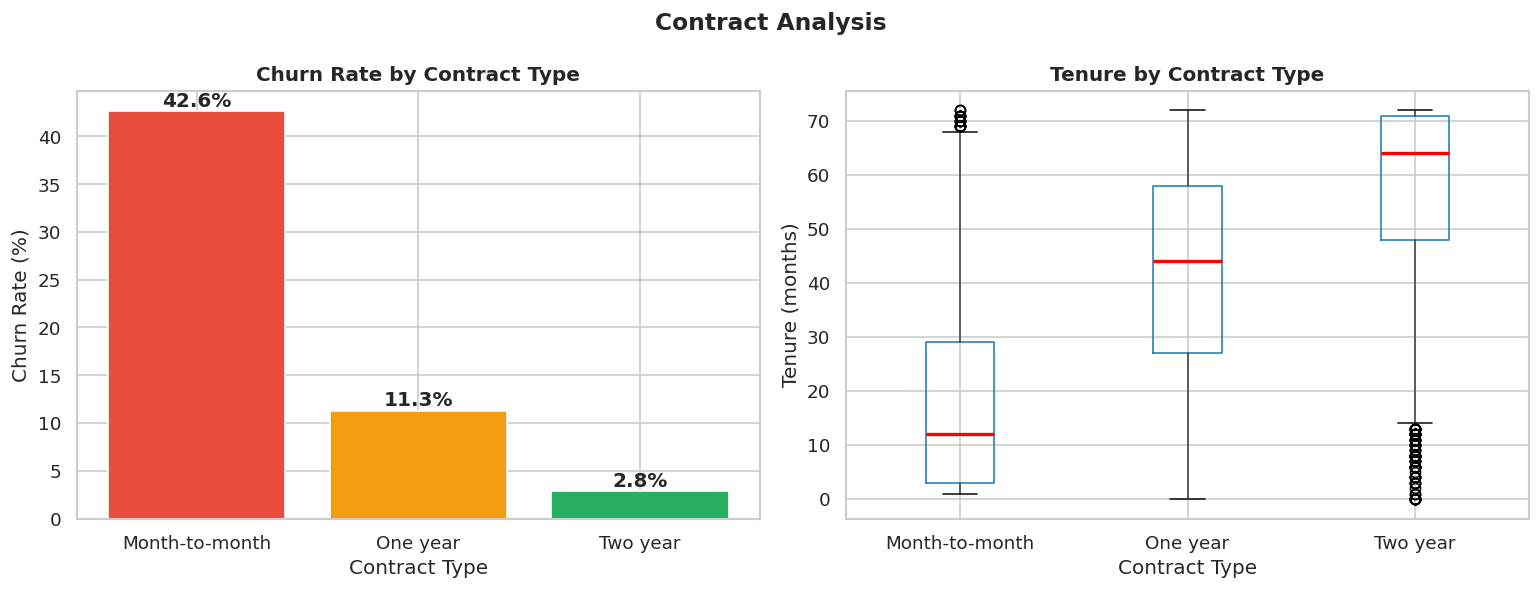

💾 Saved: DT_05_contract_analysis.png


In [16]:
# ── 5.5 Churn Rate by Contract Type
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Contract type churn rate
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
contract_churn.columns = ['Contract', 'ChurnRate']

axes[0].bar(contract_churn['Contract'], contract_churn['ChurnRate'],
            color=['#e74c3c', '#f39c12', '#27ae60'], edgecolor='white')
axes[0].set_title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn['ChurnRate']):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Tenure distribution by contract
df.boxplot(column='tenure', by='Contract', ax=axes[1],
           boxprops=dict(color='#2980b9'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Tenure by Contract Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Tenure (months)')

plt.suptitle('Contract Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('DT_05_contract_analysis.png', bbox_inches='tight')
plt.show()
print("💾 Saved: DT_05_contract_analysis.png")

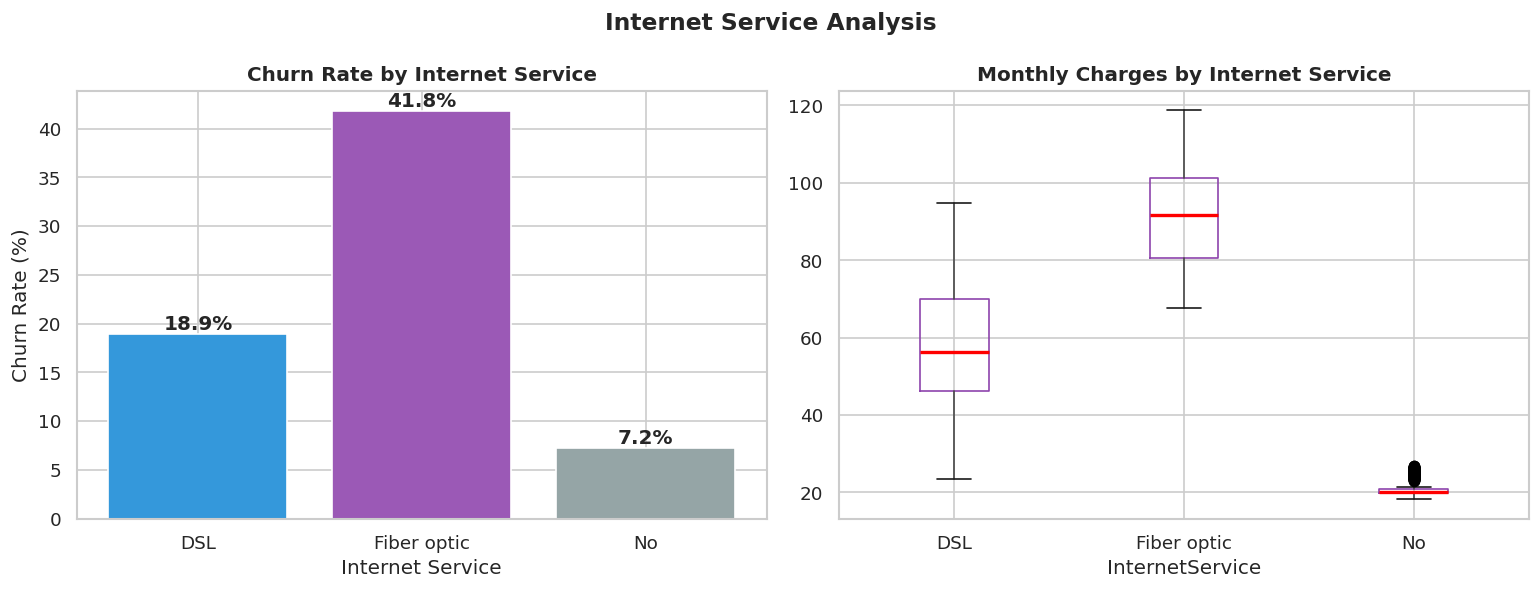

💾 Saved: DT_06_internet_analysis.png


In [17]:
# ── 5.6 Internet Service vs Churn
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
internet_churn.columns = ['InternetService', 'ChurnRate']

axes[0].bar(internet_churn['InternetService'],
            internet_churn['ChurnRate'],
            color=['#3498db', '#9b59b6', '#95a5a6'],
            edgecolor='white')
axes[0].set_title('Churn Rate by Internet Service',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Internet Service')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(internet_churn['ChurnRate']):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Monthly Charges by Internet Service
df.boxplot(column='MonthlyCharges', by='InternetService', ax=axes[1],
           boxprops=dict(color='#8e44ad'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Monthly Charges by Internet Service',
                  fontsize=12, fontweight='bold')

plt.suptitle('Internet Service Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('DT_06_internet_analysis.png', bbox_inches='tight')
plt.show()
print("💾 Saved: DT_06_internet_analysis.png")

In [18]:
# ── 6. DATA PRE-PROCESSING ───────────────────────────────────
df_model = df.copy()

# ── 6.1 Encode Target
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})
print("✅ Target encoded → Yes:1 / No:0")

# ── 6.2 Binary columns → 0/1
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines']

for col in binary_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map(binary_map)

df_model['SeniorCitizen'] = df_model['SeniorCitizen'].astype(int)
print("✅ Binary columns encoded")

# ── 6.3 Multi-class Categorical → One-Hot Encoding
multi_cat = ['InternetService', 'Contract', 'PaymentMethod',
             'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
             'TechSupport', 'StreamingTV', 'StreamingMovies']

multi_cat = [c for c in multi_cat if c in df_model.columns]
df_model = pd.get_dummies(df_model, columns=multi_cat, drop_first=True)
print(f"✅ One-Hot Encoding applied to {len(multi_cat)} columns")

# ── 6.4 Handle remaining nulls
df_model.fillna(df_model.median(numeric_only=True), inplace=True)

print(f"\n📐 Final Shape after encoding: {df_model.shape}")
df_model.head(3)

✅ Target encoded → Yes:1 / No:0
✅ Binary columns encoded
✅ One-Hot Encoding applied to 9 columns

📐 Final Shape after encoding: (7021, 30)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,PaperlessBilling,MonthlyCharges,TotalCharges,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,0,1,0,1,0,0.0,1,29.85,29.85,...,False,True,False,False,False,False,False,False,False,False
1,1,0,0,0,34,1,0.0,0,56.95,1889.50,...,False,False,False,True,False,False,False,False,False,False
2,1,0,0,0,2,1,0.0,1,53.85,108.15,...,False,True,False,False,False,False,False,False,False,False


In [19]:
# ── 6.5 Feature Engineering
print("\n⚙️  Feature Engineering...")

service_cols_raw = ['PhoneService', 'MultipleLines',
                    'OnlineSecurity_Yes', 'OnlineBackup_Yes',
                    'DeviceProtection_Yes', 'TechSupport_Yes',
                    'StreamingTV_Yes', 'StreamingMovies_Yes']

available = [c for c in service_cols_raw if c in df_model.columns]
df_model['total_services'] = df_model[available].sum(axis=1)
print("✅ 'total_services' feature created")

df_model['charges_per_tenure'] = (df_model['TotalCharges'] /
                                   (df_model['tenure'] + 1))
print("✅ 'charges_per_tenure' feature created")

print(f"\n📐 Final Shape with new features: {df_model.shape}")


⚙️  Feature Engineering...
✅ 'total_services' feature created
✅ 'charges_per_tenure' feature created

📐 Final Shape with new features: (7021, 32)


In [21]:
# ── 7. TRAIN-TEST SPLIT ──────────────────────────────────────

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print(f"🎯 Target distribution:\n{y.value_counts()}\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# NOTE: Decision Tree does NOT require scaling
# but we keep raw splits for DT
print(f"✅ Training set : {X_train.shape}")
print(f"✅ Test set     : {X_test.shape}")
print(f"✅ Features     : {X_train.shape[1]}")
print("\n📌 Note: Decision Tree does NOT require feature scaling!")

🎯 Target distribution:
Churn
0    5164
1    1857
Name: count, dtype: int64

✅ Training set : (5616, 31)
✅ Test set     : (1405, 31)
✅ Features     : 31

📌 Note: Decision Tree does NOT require feature scaling!


In [22]:
# ── 8. BASELINE DECISION TREE ────────────────────────────────
dt_baseline = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)
dt_baseline.fit(X_train, y_train)

y_pred_base      = dt_baseline.predict(X_test)
y_pred_prob_base = dt_baseline.predict_proba(X_test)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
roc_base = roc_auc_score(y_test, y_pred_prob_base)

print(f"  Accuracy (Baseline) : {acc_base*100:.2f}%")
print(f"  ROC-AUC  (Baseline) : {roc_base:.4f}")
print(f"  Max Depth           : {dt_baseline.get_depth()}")
print(f"  Total Leaves        : {dt_baseline.get_n_leaves()}")
print("\n⚠️  Baseline may be overfitting — let's tune it!")

  Accuracy (Baseline) : 73.24%
  ROC-AUC  (Baseline) : 0.6505
  Max Depth           : 29
  Total Leaves        : 1152

⚠️  Baseline may be overfitting — let's tune it!


In [23]:
# ── 9. HYPERPARAMETER TUNING (GridSearchCV) ──────────────────
param_grid = {
    'max_depth'        : [3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 8],
    'criterion'        : ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator  = DecisionTreeClassifier(
                     random_state=42,
                     class_weight='balanced'),
    param_grid = param_grid,
    cv         = StratifiedKFold(5),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print(f"\n Best Parameters : {grid_search.best_params_}")
print(f" Best CV ROC-AUC : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 224 candidates, totalling 1120 fits

 Best Parameters : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
 Best CV ROC-AUC : 0.8296


In [24]:
# ── 10. BEST DECISION TREE MODEL ─────────────────────────────
dt_best = grid_search.best_estimator_
dt_best.fit(X_train, y_train)

y_pred      = dt_best.predict(X_test)
y_pred_prob = dt_best.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
roc  = roc_auc_score(y_test, y_pred_prob)
cv   = cross_val_score(dt_best, X_train, y_train,
                       cv=StratifiedKFold(5), scoring='roc_auc')

print(f"\n{'Metric':<28} {'Score':>10}")
print("-" * 40)
print(f"{'Accuracy':<28} {acc*100:>9.2f}%")
print(f"{'ROC-AUC':<28} {roc:>10.4f}")
print(f"{'CV ROC-AUC (mean)':<28} {cv.mean():>10.4f}")
print(f"{'CV ROC-AUC (std)':<28} {cv.std():>10.4f}")
print(f"{'Tree Depth':<28} {dt_best.get_depth():>10}")
print(f"{'Number of Leaves':<28} {dt_best.get_n_leaves():>10}")

print(f"\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred,
                            target_names=['No Churn', 'Churn']))


Metric                            Score
----------------------------------------
Accuracy                         72.17%
ROC-AUC                          0.8249
CV ROC-AUC (mean)                0.8296
CV ROC-AUC (std)                 0.0068
Tree Depth                            5
Number of Leaves                     28

📋 Classification Report:

              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.48      0.79      0.60       372

    accuracy                           0.72      1405
   macro avg       0.69      0.74      0.69      1405
weighted avg       0.79      0.72      0.74      1405



In [25]:
# ── 10.1 Baseline vs Tuned Comparison
comparison = pd.DataFrame({
    'Model'   : ['Baseline DT', 'Tuned DT'],
    'Accuracy': [f"{acc_base*100:.2f}%", f"{acc*100:.2f}%"],
    'ROC-AUC' : [f"{roc_base:.4f}", f"{roc:.4f}"],
    'Depth'   : [dt_baseline.get_depth(), dt_best.get_depth()],
    'Leaves'  : [dt_baseline.get_n_leaves(), dt_best.get_n_leaves()]
})
print(comparison.to_string(index=False))

📊 BASELINE vs TUNED COMPARISON
      Model Accuracy ROC-AUC  Depth  Leaves
Baseline DT   73.24%  0.6505     29    1152
   Tuned DT   72.17%  0.8249      5      28


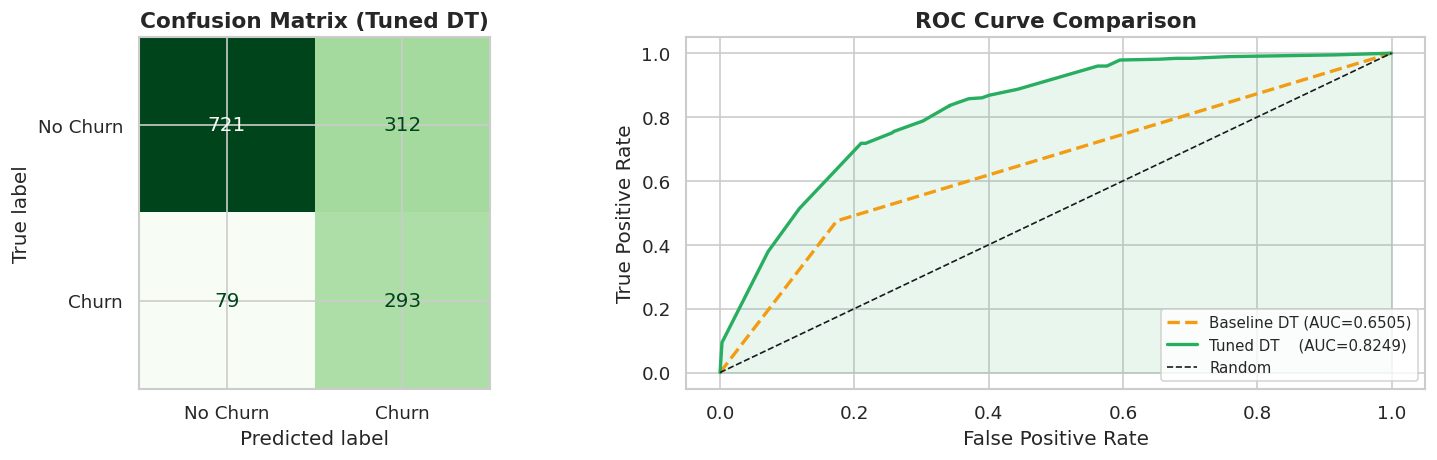

💾 Saved: DT_07_confusion_roc.png


In [26]:
# ── 11. MODEL EVALUATION PLOTS ───────────────────────────────

# ── 11.1 Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix (Tuned DT)',
                  fontsize=13, fontweight='bold')

# ROC Curve — Baseline vs Tuned
fpr_base, tpr_base, _ = roc_curve(y_test, y_pred_prob_base)
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_prob)

axes[1].plot(fpr_base, tpr_base, color='#f39c12', lw=2, linestyle='--',
             label=f'Baseline DT (AUC={roc_base:.4f})')
axes[1].plot(fpr_best, tpr_best, color='#27ae60', lw=2,
             label=f'Tuned DT    (AUC={roc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random')
axes[1].fill_between(fpr_best, tpr_best, alpha=0.1, color='#27ae60')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('DT_07_confusion_roc.png', bbox_inches='tight')
plt.show()
print("💾 Saved: DT_07_confusion_roc.png")

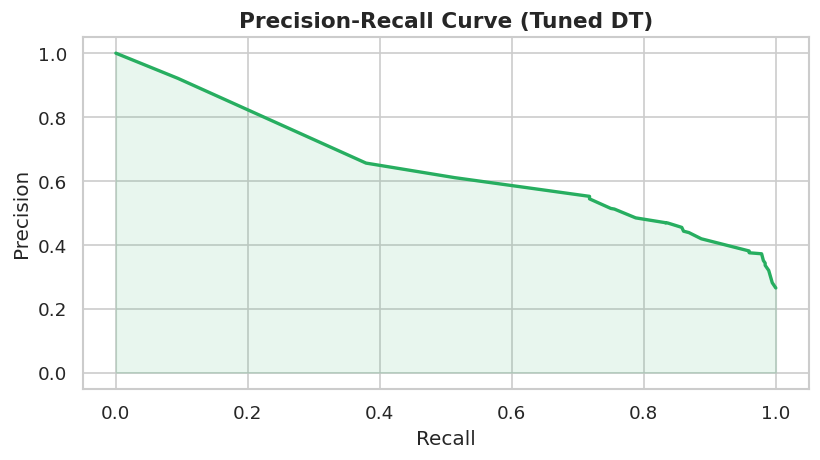

💾 Saved: DT_08_precision_recall.png


In [27]:
# ── 11.2 Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(recall, precision, color='#27ae60', lw=2)
ax.fill_between(recall, precision, alpha=0.1, color='#27ae60')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Tuned DT)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('DT_08_precision_recall.png', bbox_inches='tight')
plt.show()
print("💾 Saved: DT_08_precision_recall.png")

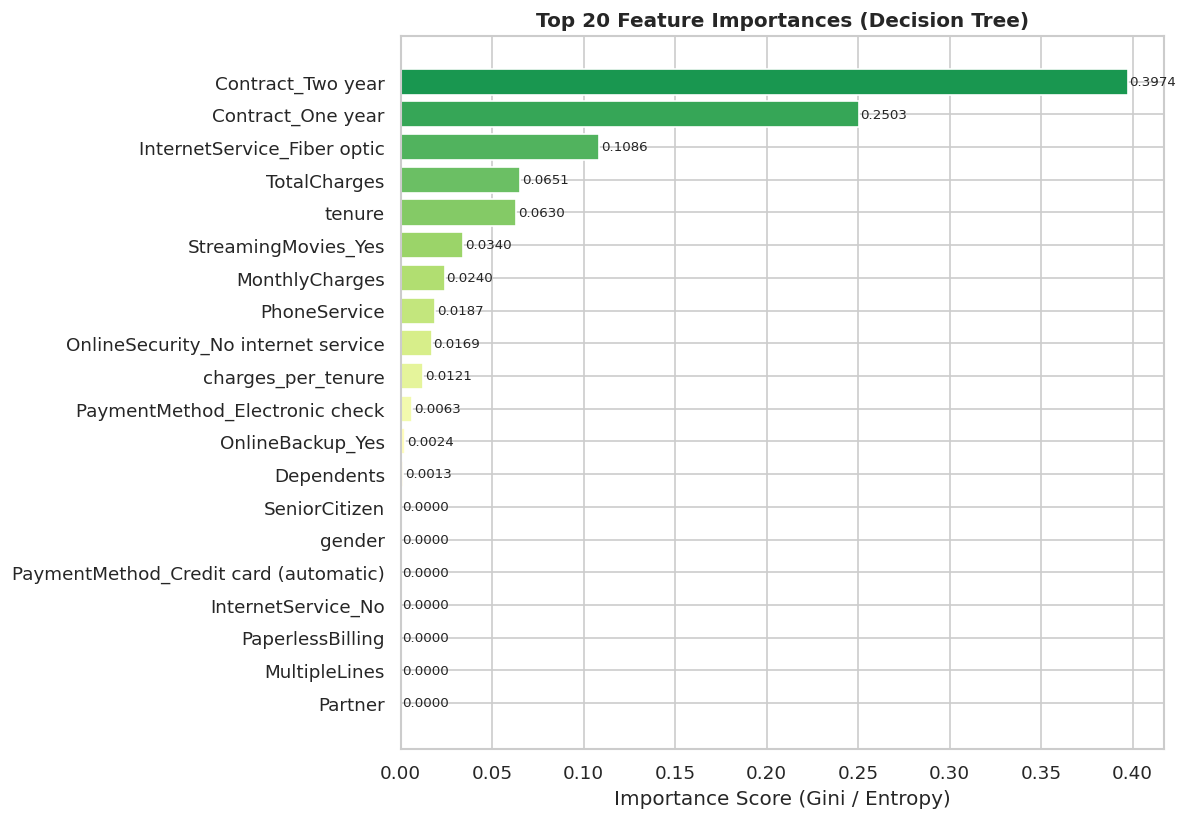

💾 Saved: DT_09_feature_importance.png


In [28]:
# ── 11.3 Feature Importance (Top 20)
feature_names = X.columns.tolist()
importances   = dt_best.feature_importances_

feat_imp = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(feat_imp))
)[::-1]

bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'],
               color=colors, edgecolor='white')
ax.set_title('Top 20 Feature Importances (Decision Tree)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score (Gini / Entropy)')
ax.invert_yaxis()

for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('DT_09_feature_importance.png', bbox_inches='tight')
plt.show()
print("💾 Saved: DT_09_feature_importance.png")

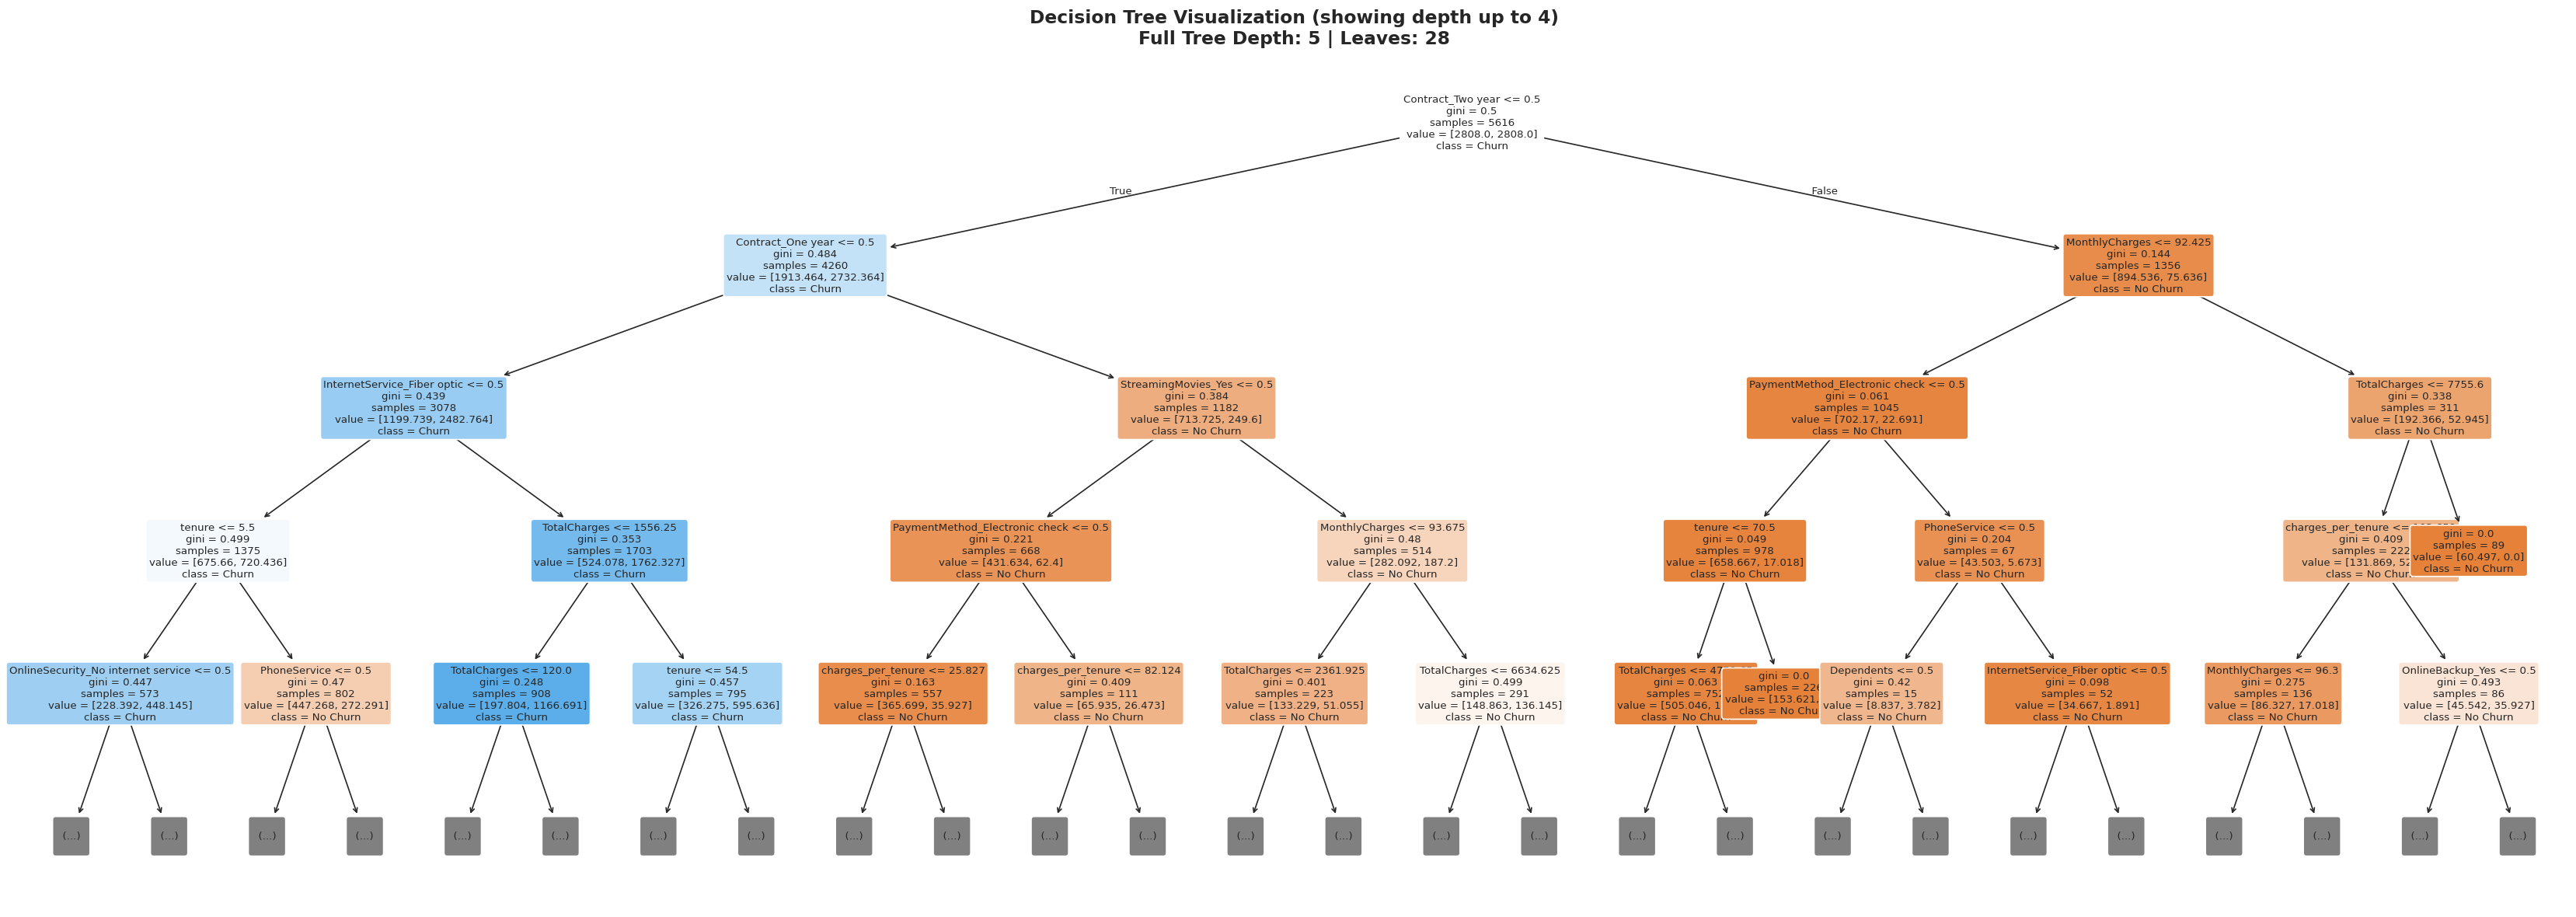

💾 Saved: DT_10_tree_visualization.png


In [29]:
# ── 11.4 Decision Tree Visualization (max_depth=4 for clarity)
fig, ax = plt.subplots(figsize=(28, 10))

plot_tree(
    dt_best,
    max_depth       = 4,
    feature_names   = feature_names,
    class_names     = ['No Churn', 'Churn'],
    filled          = True,
    rounded         = True,
    fontsize        = 8,
    ax              = ax,
    impurity        = True,
    proportion      = False
)

ax.set_title(
    f'Decision Tree Visualization (showing depth up to 4)\n'
    f'Full Tree Depth: {dt_best.get_depth()} | '
    f'Leaves: {dt_best.get_n_leaves()}',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('DT_10_tree_visualization.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("💾 Saved: DT_10_tree_visualization.png")

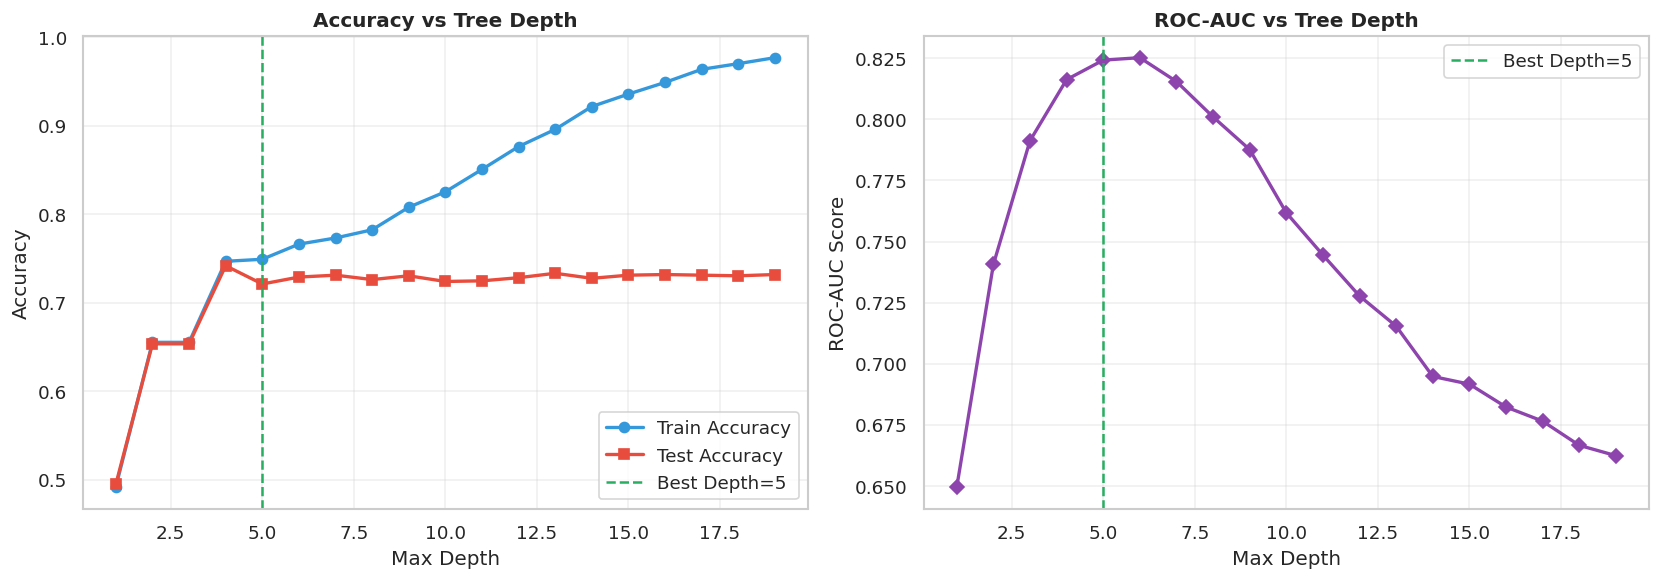

💾 Saved: DT_11_depth_analysis.png


In [30]:
# ── 11.5 Depth vs Accuracy / ROC-AUC Analysis
depths    = range(1, 20)
train_acc = []
test_acc  = []
test_roc  = []

for d in depths:
    dt_temp = DecisionTreeClassifier(
        max_depth    = d,
        random_state = 42,
        class_weight = 'balanced'
    )
    dt_temp.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, dt_temp.predict(X_train)))
    test_acc.append(accuracy_score(y_test,  dt_temp.predict(X_test)))
    test_roc.append(roc_auc_score(y_test,
                    dt_temp.predict_proba(X_test)[:, 1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy vs Depth
axes[0].plot(depths, train_acc, 'o-', color='#3498db',
             label='Train Accuracy', lw=2)
axes[0].plot(depths, test_acc,  's-', color='#e74c3c',
             label='Test Accuracy',  lw=2)
axes[0].axvline(x=dt_best.get_depth(), color='#27ae60',
                linestyle='--', label=f'Best Depth={dt_best.get_depth()}')
axes[0].set_title('Accuracy vs Tree Depth', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Max Depth')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ROC-AUC vs Depth
axes[1].plot(depths, test_roc, 'D-', color='#8e44ad', lw=2)
axes[1].axvline(x=dt_best.get_depth(), color='#27ae60',
                linestyle='--', label=f'Best Depth={dt_best.get_depth()}')
axes[1].set_title('ROC-AUC vs Tree Depth', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('DT_11_depth_analysis.png', bbox_inches='tight')
plt.show()
print("💾 Saved: DT_11_depth_analysis.png")

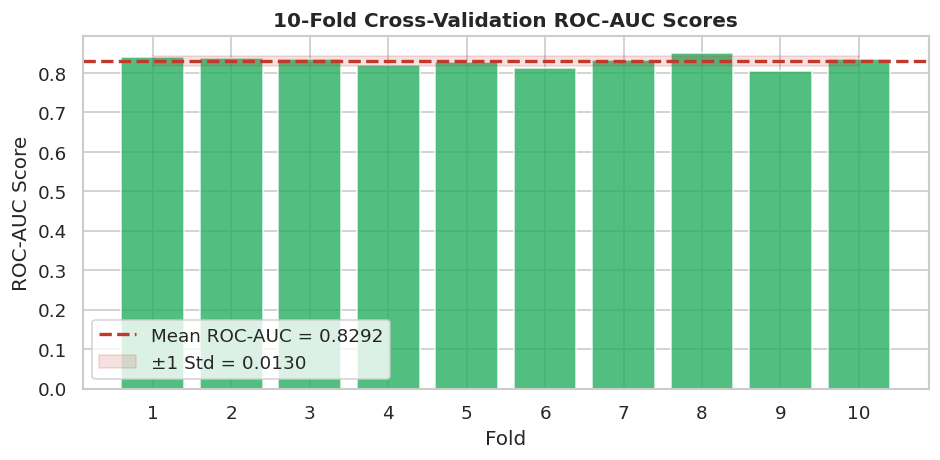

💾 Saved: DT_12_cv_scores.png


In [31]:
# ── 11.6 Cross-Validation Score Distribution
cv_scores = cross_val_score(dt_best, X_train, y_train,
                            cv=StratifiedKFold(10),
                            scoring='roc_auc')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 11), cv_scores, color='#27ae60',
       edgecolor='white', alpha=0.8)
ax.axhline(y=cv_scores.mean(), color='#c0392b',
           linestyle='--', lw=2,
           label=f'Mean ROC-AUC = {cv_scores.mean():.4f}')
ax.fill_between(range(1, 11),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.15, color='#c0392b',
                label=f'±1 Std = {cv_scores.std():.4f}')
ax.set_title('10-Fold Cross-Validation ROC-AUC Scores',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('ROC-AUC Score')
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.savefig('DT_12_cv_scores.png', bbox_inches='tight')
plt.show()
print("💾 Saved: DT_12_cv_scores.png")

In [32]:
# ── 12. DECISION TREE RULES (TEXT) ───────────────────────────
tree_rules = export_text(
    dt_best,
    feature_names = feature_names,
    max_depth     = 3
)
print(tree_rules)

# Save rules to file
with open('DT_tree_rules.txt', 'w') as f:
    full_rules = export_text(dt_best, feature_names=feature_names)
    f.write(full_rules)
print("💾 Full tree rules saved → DT_tree_rules.txt")

|--- Contract_Two year <= 0.50
|   |--- Contract_One year <= 0.50
|   |   |--- InternetService_Fiber optic <= 0.50
|   |   |   |--- tenure <= 5.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- tenure >  5.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- InternetService_Fiber optic >  0.50
|   |   |   |--- TotalCharges <= 1556.25
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- TotalCharges >  1556.25
|   |   |   |   |--- truncated branch of depth 2
|   |--- Contract_One year >  0.50
|   |   |--- StreamingMovies_Yes <= 0.50
|   |   |   |--- PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- StreamingMovies_Yes >  0.50
|   |   |   |--- MonthlyCharges <= 93.68
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- MonthlyCharges >  93.68
|   |   |   |   |--- truncated branc

In [33]:
# ── 13. SAVE / DOWNLOAD MODEL ────────────────────────────────

# Save tuned Decision Tree model
joblib.dump(dt_best, 'decision_tree_churn_model.pkl')
print("✅ Model saved  → decision_tree_churn_model.pkl")

# Save feature names
feature_df = pd.DataFrame({'features': feature_names})
feature_df.to_csv('DT_feature_names.csv', index=False)
print("✅ Features saved → DT_feature_names.csv")

# Save GridSearch results
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results.to_csv('DT_gridsearch_results.csv', index=False)
print("✅ GridSearch results → DT_gridsearch_results.csv")

# ── Download in Google Colab ──────────────────────────────────
try:
    from google.colab import files
    files.download('decision_tree_churn_model.pkl')
    files.download('DT_feature_names.csv')
    files.download('DT_tree_rules.txt')
    files.download('DT_gridsearch_results.csv')
    print("\n🎉 Files downloaded to your PC!")
except ImportError:
    print("\n📁 Not in Colab — files saved in current directory:")
    print(f"   → {os.path.abspath('decision_tree_churn_model.pkl')}")
    print(f"   → {os.path.abspath('DT_feature_names.csv')}")
    print(f"   → {os.path.abspath('DT_tree_rules.txt')}")

✅ Model saved  → decision_tree_churn_model.pkl
✅ Features saved → DT_feature_names.csv
✅ GridSearch results → DT_gridsearch_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Files downloaded to your PC!


In [35]:
# ── 14. LOAD & USE MODEL (Demo) ───────────────────────────────
loaded_model = joblib.load('decision_tree_churn_model.pkl')

# Demo prediction
sample      = X_test.iloc[:5]
predictions = loaded_model.predict(sample)
proba       = loaded_model.predict_proba(sample)[:, 1]

print("\n📊 Sample Predictions:")
print(f"{'#':<5} {'Prediction':<15} {'Churn Probability':>18} {'Actual':>10}")
print("-" * 52)
for i, (pred, prob, actual) in enumerate(
        zip(predictions, proba, y_test.values[:5])):
    label  = "⚠️ CHURN"   if pred   == 1 else "✅ NO CHURN"
    actual_label = "CHURN" if actual == 1 else "NO CHURN"
    print(f"{i+1:<5} {label:<15} {prob*100:>16.2f}% {actual_label:>10}")

print("\n✅ Model loaded and working perfectly!")


📊 Sample Predictions:
#     Prediction       Churn Probability     Actual
----------------------------------------------------
1     ⚠️ CHURN                   82.76%   NO CHURN
2     ⚠️ CHURN                   67.68%      CHURN
3     ⚠️ CHURN                   73.88%      CHURN
4     ✅ NO CHURN                 32.87%   NO CHURN
5     ✅ NO CHURN                 32.87%   NO CHURN

✅ Model loaded and working perfectly!


In [36]:
# ── 15. FINAL SUMMARY ────────────────────────────────────────
print("\n" + "=" * 55)
print("🎯 FINAL SUMMARY - DECISION TREE")
print("=" * 55)
print(f"  Dataset Shape             : {df.shape}")
print(f"  Features Used             : {X.shape[1]}")
print(f"  Training Samples          : {X_train.shape[0]}")
print(f"  Test Samples              : {X_test.shape[0]}")
print(f"  Best Parameters           : {grid_search.best_params_}")
print(f"  Baseline Accuracy         : {acc_base*100:.2f}%")
print(f"  Tuned Accuracy            : {acc*100:.2f}%")
print(f"  Baseline ROC-AUC          : {roc_base:.4f}")
print(f"  Tuned ROC-AUC             : {roc:.4f}")
print(f"  CV ROC-AUC (5-fold mean)  : {cv.mean():.4f} ± {cv.std():.4f}")
print(f"  Tree Depth                : {dt_best.get_depth()}")
print(f"  Number of Leaves          : {dt_best.get_n_leaves()}")
print("=" * 55)
print("📦 Saved Files:")
print("  🌳 decision_tree_churn_model.pkl")
print("  📋 DT_feature_names.csv")
print("  📜 DT_tree_rules.txt")
print("  📊 DT_gridsearch_results.csv")
print("  🖼️  DT_01 ~ DT_12 PNG visualization files")
print("=" * 55)
print("✅ Decision Tree Pipeline Complete!")


🎯 FINAL SUMMARY - DECISION TREE
  Dataset Shape             : (7021, 20)
  Features Used             : 31
  Training Samples          : 5616
  Test Samples              : 1405
  Best Parameters           : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
  Baseline Accuracy         : 73.24%
  Tuned Accuracy            : 72.17%
  Baseline ROC-AUC          : 0.6505
  Tuned ROC-AUC             : 0.8249
  CV ROC-AUC (5-fold mean)  : 0.8296 ± 0.0068
  Tree Depth                : 5
  Number of Leaves          : 28
📦 Saved Files:
  🌳 decision_tree_churn_model.pkl
  📋 DT_feature_names.csv
  📜 DT_tree_rules.txt
  📊 DT_gridsearch_results.csv
  🖼️  DT_01 ~ DT_12 PNG visualization files
✅ Decision Tree Pipeline Complete!
